# Práctica Final: Aprendizaje Profundo - Unidad I
## Desarrollo de un Sistema Inteligente de Reconocimiento de Imágenes

**Objetivo General:** Implementar un sistema de reconocimiento automático utilizando CNN, Transfer Learning y Fine-Tuning, aplicando rigor metodológico en la partición de datos y evaluación.

**Dataset:** CIFAR-10 (Versión estándar de `tf.keras.datasets`). Consta de 60,000 imágenes RGB de 32x32 píxeles (50,000 para desarrollo, 10,000 para prueba final), agrupadas en 10 clases de objetos.

In [1]:
# ==========================================
# 1. CONFIGURACIÓN DEL ENTORNO Y OPTIMIZACIÓN
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Precisión mixta para acelerar el entrenamiento en GPUs modernas (T4, A100)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print("Versión de TensorFlow:", tf.__version__)
print("GPUs detectadas:", tf.config.list_physical_devices('GPU'))

# Diccionario para almacenar el rendimiento comparativo final
resultados_evaluacion = {}

BATCH_SIZE = 64
EPOCHS = 10

2026-06-04 12:15:25.675437: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780575325.910684      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780575325.969621      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780575326.479147      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780575326.479204      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780575326.479208      58 computation_placer.cc:177] computation placer alr

Versión de TensorFlow: 2.19.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Metodología de Datos: División Train / Val / Test
Para garantizar la validez científica del modelo, se separa el conjunto original de entrenamiento en `Entrenamiento` (80%) y `Validación` (20%). El conjunto de `Prueba` (test) se aísla por completo y solo se utilizará al final del experimento para evitar fugas de información.

In [2]:
# ==========================================
# 2. CARGA Y PARTICIÓN ESTRICTA DE DATOS
# ==========================================
# Carga del dataset oficial CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo', 
               'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']
NUM_CLASSES = len(class_names)

# Partición Estratégica: Separar x_train_full en Entrenamiento (80%) y Validación (20%)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Set de Entrenamiento (x_train): {x_train.shape}")
print(f"Set de Validación  (x_val):   {x_val.shape}")
print(f"Set de Prueba Pura (x_test):  {x_test.shape}")

# Construcción de pipelines eficientes para la GPU
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Función auxiliar para graficar el entrenamiento
def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de Precisión (Accuracy)
    ax1.plot(history.history['accuracy'], label='Entrenamiento')
    ax1.plot(history.history['val_accuracy'], label='Validación')
    ax1.set_title(f'Precisión - {title}')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Gráfico de Pérdida (Loss)
    ax2.plot(history.history['loss'], label='Entrenamiento')
    ax2.plot(history.history['val_loss'], label='Validación')
    ax2.set_title(f'Pérdida - {title}')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Set de Entrenamiento (x_train): (40000, 32, 32, 3)
Set de Validación  (x_val):   (10000, 32, 32, 3)
Set de Prueba Pura (x_test):  (10000, 32, 32, 3)


I0000 00:00:1780575344.727408      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780575344.733387      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3. Arquitectura Base: CNN Propia (Optimizada)
Implementación de una red convolucional desde cero.
**Mejora:** Se reemplaza `Flatten` por `GlobalAveragePooling2D`. Esto reduce drásticamente el número de parámetros de la red, mitigando el sobreajuste y forzando a la red a encontrar características globales más sólidas.

Iniciando entrenamiento de la CNN Propia...
Epoch 1/10


I0000 00:00:1780575350.332249     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3642 - loss: 1.7318 - val_accuracy: 0.4131 - val_loss: 1.8136 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4516 - loss: 1.5146 - val_accuracy: 0.3797 - val_loss: 1.8971 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4825 - loss: 1.4309 - val_accuracy: 0.4947 - val_loss: 1.4750 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5068 - loss: 1.3715 - val_accuracy: 0.3903 - val_loss: 1.9900 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5239 - loss: 1.3266 - val_accuracy: 0.4572 - val_loss: 1.6097 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5475 - loss: 1.2652 - val_accuracy: 0.5326 - val_loss: 1.3185 - learning_rate: 5.0000e-04
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5582 - loss: 1.2365 -

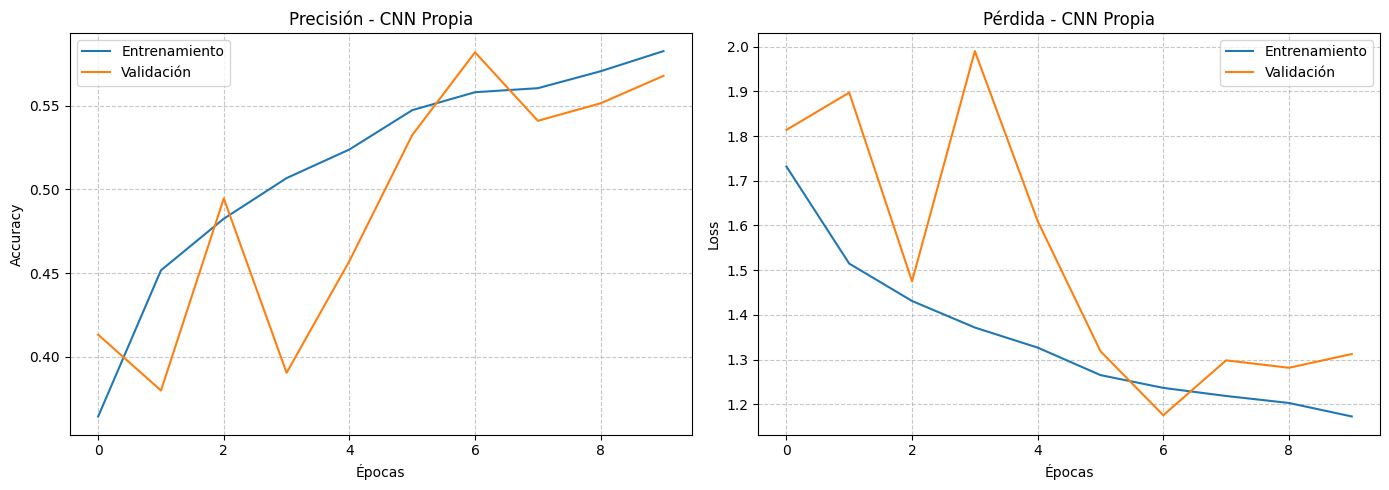

In [3]:
# ==========================================
# 3. CNN PROPIA CON GLOBAL AVERAGE POOLING
# ==========================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name="aumento_datos")

cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    
    # Bloque Convolucional 1
    layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    
    # Bloque Convolucional 2
    layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    
    # Bloque Convolucional 3
    layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Reemplazo de Flatten por GlobalAveragePooling2D
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    
    # Capa de salida (forzando float32 para la precisión mixta)
    layers.Dense(NUM_CLASSES, activation="softmax", dtype='float32') 
], name="CNN_Propia")

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_cnn = [
    EarlyStopping(patience=4, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-5),
    ModelCheckpoint("cnn_propia.keras", save_best_only=True, monitor='val_accuracy') # Guarda el mejor modelo
]

print("Iniciando entrenamiento de la CNN Propia...")
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_cnn
)

plot_training_history(history_cnn, "CNN Propia")

# Evaluación formal en el set de PRUEBA (nunca visto)
loss, acc = cnn_model.evaluate(test_ds, verbose=0)
resultados_evaluacion['1. CNN Propia'] = acc

## 4. Transfer Learning con EfficientNetB0 (Con Preprocesamiento Oficial)
Se implementa EfficientNetB0 preentrenado en ImageNet. 
**Mejora:** Se añade `layers.Lambda(preprocess_input)` explícitamente para alinear las distribuciones estadísticas de las imágenes de entrada con los tensores con los que ImageNet entrenó la arquitectura original.

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iniciando entrenamiento de Transfer Learning...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 167ms/step - accuracy: 0.6314 - loss: 1.0772 - val_accuracy: 0.8568 - val_loss: 0.4409 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7041 - loss: 0.8483 - val_accuracy: 0.8655 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7171 - loss: 0.8054 - val_accuracy: 0.8710 - val_loss: 0.3867 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7255 - loss: 0.7863 - val_accuracy: 0.8767 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7276 - loss: 0.7769 - val_accuracy: 0.8798 - val_loss: 0.3686 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7305 - loss: 0.7734 - val_accuracy: 0.8799 - val_loss: 0

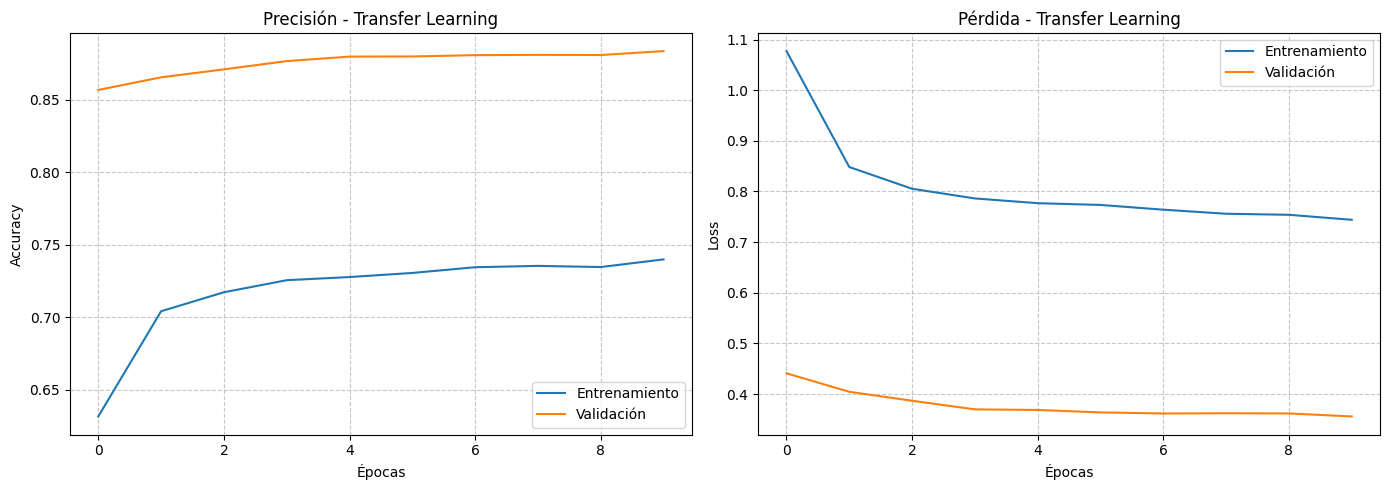

In [4]:
# ==========================================
# 4. TRANSFER LEARNING (EFFICIENTNETB0)
# ==========================================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False # Congelar pesos base

inputs = layers.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

# Escalado dinámico por GPU
x = layers.Resizing(224, 224)(x)

# Uso explícito del preprocesamiento oficial de la arquitectura envolviéndolo en capa Lambda
# Esto asegura su correcta serialización al exportar el modelo a .keras
x = layers.Lambda(preprocess_input)(x)

# Extracción de características
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype='float32')(x)

efficient_model = models.Model(inputs, outputs, name="EfficientNetB0_TransferLearning")

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_tl = [
    EarlyStopping(patience=4, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-5),
    ModelCheckpoint("efficientnet_tl.keras", save_best_only=True, monitor='val_accuracy') # Guarda el mejor modelo
]

print("Iniciando entrenamiento de Transfer Learning...")
history_tl = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_tl
)

plot_training_history(history_tl, "Transfer Learning")

# Evaluación formal en el set de PRUEBA
loss, acc = efficient_model.evaluate(test_ds, verbose=0)
resultados_evaluacion['2. Transfer Learning'] = acc

## 5. Fine-Tuning
Descongelamos las últimas 20 capas del modelo para ajustar los filtros de convolución profundos (que detectan formas complejas) a las particularidades morfológicas de CIFAR-10. Mantenemos el ModelCheckpoint para asegurar el almacenamiento del pico de rendimiento.

Iniciando Fine-Tuning...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 156ms/step - accuracy: 0.6813 - loss: 0.9413 - val_accuracy: 0.8616 - val_loss: 0.4260
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.7181 - loss: 0.8211 - val_accuracy: 0.8751 - val_loss: 0.3879
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.7343 - loss: 0.7698 - val_accuracy: 0.8831 - val_loss: 0.3634
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.7458 - loss: 0.7408 - val_accuracy: 0.8871 - val_loss: 0.3467
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.7574 - loss: 0.7001 - val_accuracy: 0.8909 - val_loss: 0.3357


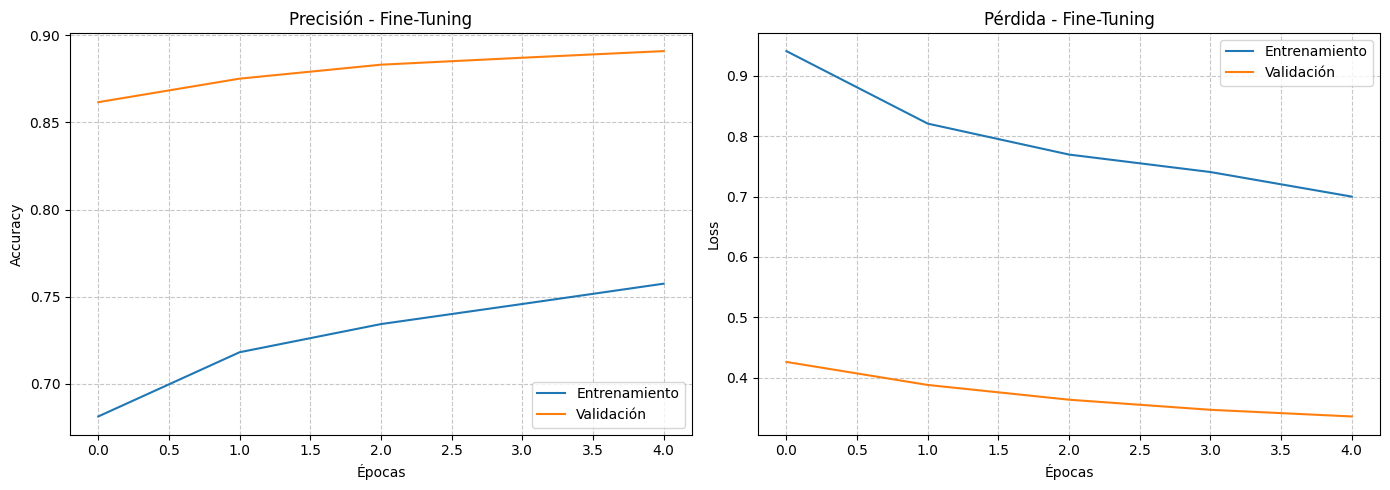

Modelo final exportado exitosamente como: modelo_final_cifar10.keras


In [5]:
# ==========================================
# 5. FINE-TUNING
# ==========================================
base_model.trainable = True

# Congelar todas excepto las últimas 20 capas
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompilamos con una tasa de aprendizaje (Learning Rate) minúscula
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_ft = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint("modelo_final_cifar10.keras", save_best_only=True, monitor='val_accuracy') # Exportación final
]

print("Iniciando Fine-Tuning...")
history_ft = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks_ft
)

plot_training_history(history_ft, "Fine-Tuning")

# Evaluación formal en el set de PRUEBA
loss, acc = efficient_model.evaluate(test_ds, verbose=0)
resultados_evaluacion['3. Fine-Tuning'] = acc

print("Modelo final exportado exitosamente como: modelo_final_cifar10.keras")

## 6. Resultados y Comparación Formal
Se evalúa el rendimiento del modelo óptimo sobre el conjunto de prueba aislado para emitir métricas realistas y se contrastan los tres enfoques de la práctica.

 COMPARACIÓN FORMAL DE MODELOS (Datos Test)
1. CNN Propia         : 57.04% de Exactitud
2. Transfer Learning  : 88.21% de Exactitud
3. Fine-Tuning        : 89.38% de Exactitud

--- Reporte de Clasificación (Modelo Final) ---
              precision    recall  f1-score   support

       Avión       0.93      0.86      0.89      1000
   Automóvil       0.93      0.94      0.94      1000
      Pájaro       0.91      0.83      0.87      1000
        Gato       0.86      0.77      0.81      1000
      Ciervo       0.89      0.87      0.88      1000
       Perro       0.84      0.87      0.86      1000
        Rana       0.87      0.96      0.91      1000
     Caballo       0.90      0.93      0.92      1000
       Barco       0.92      0.94      0.93      1000
      Camión       0.88      0.96      0.92      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



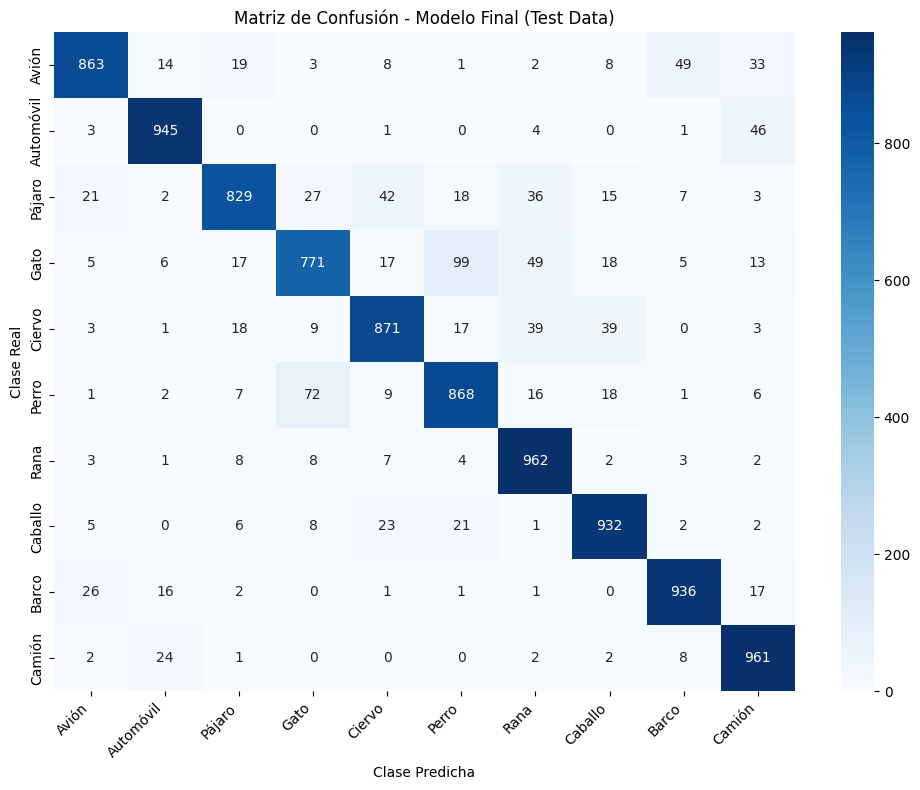

In [6]:
# ==========================================
# 6. EVALUACIÓN COMPARATIVA Y MATRIZ DE CONFUSIÓN
# ==========================================
print("========================================")
print(" COMPARACIÓN FORMAL DE MODELOS (Datos Test)")
print("========================================")
for modelo, precision in resultados_evaluacion.items():
    print(f"{modelo:<22}: {precision*100:.2f}% de Exactitud")
print("========================================\n")

# Extraer predicciones del mejor modelo (Fine-Tuning) sobre datos no vistos
y_true = np.concatenate([y for x, y in test_ds], axis=0).flatten()
y_pred_probs = efficient_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("--- Reporte de Clasificación (Modelo Final) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de Confusión Final
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - Modelo Final (Test Data)")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

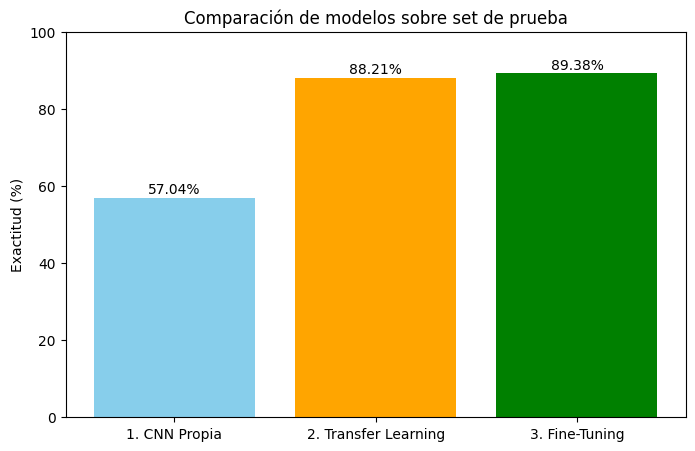

In [7]:
modelos = list(resultados_evaluacion.keys())
acc = [v*100 for v in resultados_evaluacion.values()]

plt.figure(figsize=(8,5))
plt.bar(modelos, acc, color=['skyblue', 'orange', 'green'])
plt.ylabel("Exactitud (%)")
plt.title("Comparación de modelos sobre set de prueba")
plt.ylim(0, 100)
for i, v in enumerate(acc):
    plt.text(i, v+1, f"{v:.2f}%", ha='center')
plt.show()

### 1. ¿Por qué una CNN es más adecuada que una red neuronal densa tradicional para imágenes?

Una red neuronal densa (Multilayer Perceptron) sufre de un problema crítico al procesar imágenes: **la explosión de la dimensionalidad y la pérdida de la estructura espacial**. Si procesamos una imagen RGB de 224x224, una capa densa requeriría aplanar la imagen en un vector de 150,528 elementos. Conectar esto a una capa oculta de 512 neuronas generaría más de 77 millones de pesos solo en esa conexión, provocando un sobreajuste masivo y requiriendo un poder computacional inviable.

Por el contrario, las Redes Neuronales Convolucionales (CNN) son adecuadas por dos principios matemáticos:

* **Conectividad local (Campos receptivos):** Cada neurona solo se conecta a una pequeña región de la imagen (por ejemplo, 3x3 píxeles), preservando la relación espacial entre píxeles adyacentes.
* **Compartición de pesos (Weight sharing):** El mismo filtro (kernel) se desliza por toda la imagen. Esto significa que si la red aprende a detectar un borde horizontal en la esquina superior izquierda, puede detectar ese mismo borde en la esquina inferior derecha sin tener que aprenderlo de nuevo (invarianza a la traslación).

---

### 2. ¿Qué función cumplen los filtros o kernels en una convolución?

Los kernels actúan como **extractores jerárquicos de características** mediante la operación matemática de convolución (estrictamente, correlación cruzada discreta).

* **En las capas iniciales:** Los filtros detectan patrones primitivos de bajo nivel, como bordes, gradientes de color o líneas en diferentes ángulos (similares a los filtros de Gabor en el procesamiento clásico).
* **En las capas profundas:** A medida que la información avanza, las convoluciones combinan estos patrones primitivos para construir representaciones semánticas complejas (texturas de follaje, techos de casas, formas de vehículos).

El entrenamiento de la red consiste, esencialmente, en que el algoritmo de retropropagación optimice los valores numéricos de estas matrices (kernels) para que extraigan las características más útiles para la clasificación.

---

### 3. ¿Por qué se utiliza ReLU en capas ocultas y Softmax en la capa de salida?

Ambas funciones de activación tienen propósitos matemáticos diametralmente distintos:

* **ReLU (Rectified Linear Unit) en capas ocultas:** Definida como $f(x) = \max(0, x)$, ReLU se utiliza porque mitiga el **problema del desvanecimiento del gradiente** que sufren funciones como la sigmoide o tangente hiperbólica. Al tener un gradiente constante de 1 para valores positivos, permite que el error retropropague eficientemente a través de redes muy profundas. Además, induce dispersión (sparsity), ya que apaga (salida cero) las neuronas con valores negativos, haciendo la red computacionalmente más eficiente.
* **Softmax en la capa de salida:** Transforma los valores brutos (logits) producidos por la última capa en una **distribución de probabilidad discreta**. Exponencia los valores y los normaliza para que todos los resultados sumen exactamente 1 (o 100%). Esto permite evaluar la "confianza" del modelo en su predicción y calcular la pérdida mediante entropía cruzada (*Cross-Entropy Loss*), penalizando fuertemente al modelo cuando está seguro de una respuesta incorrecta.

---

### 4. ¿Qué ventaja ofrece Adam frente al descenso de gradiente clásico?

El Descenso de Gradiente Estocástico (SGD) clásico utiliza una única tasa de aprendizaje global (Learning Rate) para actualizar todos los pesos, lo que provoca que el entrenamiento sea lento, oscilante y propenso a quedarse estancado en mínimos locales o puntos de silla (*saddle points*).

**Adam (Adaptive Moment Estimation)** resuelve esto calculando tasas de aprendizaje adaptativas e individuales para cada parámetro de la red. Lo logra combinando dos mecanismos:

1. **Momentum (Primer momento):** Mantiene una media móvil de los gradientes pasados para suavizar la trayectoria y acelerar en direcciones con varianza baja (como una bola rodando por una colina).
2. **RMSProp (Segundo momento):** Escala el gradiente de forma inversamente proporcional a la raíz cuadrada de la suma de los gradientes cuadrados pasados, reduciendo los saltos bruscos.

Esta combinación permite que Adam converja mucho más rápido y requiera menos sintonización fina del *learning rate* inicial.

---

### 5. ¿Qué diferencia existe entre Transfer Learning y Fine-Tuning?

Aunque suelen usarse en conjunto, representan dos fases operativas distintas:

* **Transfer Learning (Extracción de características):** Consiste en tomar un modelo preentrenado en un conjunto masivo de datos (como EfficientNetB0 en ImageNet) y **congelar** sus pesos convolucionales. El modelo se usa puramente como un extractor de características. Solo se entrena desde cero la última capa densa (el clasificador) para adaptarla a las nuevas clases (por ejemplo, las 10 clases de CIFAR-10 o EuroSAT). Es rápido y no destruye el conocimiento previo.
* **Fine-Tuning (Ajuste fino):** Va un paso más allá. Después de que el clasificador ha convergido, se **descongelan** las últimas capas convolucionales del modelo base y se entrenan junto con el clasificador utilizando una tasa de aprendizaje extremadamente baja (ej. `1e-5`). El objetivo es alterar sutilmente los filtros profundos para que se adapten a las peculiaridades de los nuevos datos, sin provocar un "olvido catastrófico" de las características generales aprendidas en ImageNet.

---

### 6. ¿Qué evidencia muestra que el modelo generaliza y no solo memoriza?

La memorización (sobreajuste o *overfitting*) ocurre cuando un modelo obtiene una exactitud cercana al 100% en los datos de entrenamiento, pero falla estrepitosamente con datos nuevos. Las evidencias de generalización en el proyecto son:

1. **Convergencia de curvas (Loss/Accuracy):** Durante el entrenamiento, si la curva de precisión de validación (`val_accuracy`) sigue de cerca a la precisión de entrenamiento (`accuracy`) y la pérdida de validación no se dispara hacia arriba, significa que el modelo está aprendiendo patrones subyacentes, no memorizando ruido.
2. **Rendimiento en el Set de Prueba Aislado:** La validación más crítica es la evaluación final sobre el conjunto de prueba puro (`test_ds`), el cual la red jamás "vio" durante ninguna etapa de entrenamiento o ajuste de hiperparámetros.
3. **Resultados de la Matriz de Confusión:** Una matriz que muestra una diagonal fuerte y equilibrada indica que el modelo distingue correctamente las fronteras de decisión entre clases sin sesgarse hacia una clase mayoritaria.

---

### 7. ¿Cómo se podría adaptar este sistema a minería ilegal, agricultura inteligente o monitoreo ambiental en Puno?

Para el contexto geográfico y socioeconómico de Puno, el sistema basado en CNN y Transfer Learning es altamente transferible si se alimenta con imágenes satelitales (como EuroSAT/Sentinel-2) o de drones:

* **Monitoreo Ambiental (Lago Titicaca):** Se puede entrenar un modelo para clasificar la cobertura de la superficie del lago, detectando la proliferación de lenteja de agua (eutrofización) o mapeando la contaminación por metales pesados en la bahía de Puno mediante el análisis de la reflectancia en imágenes multiespectrales.
* **Minería Ilegal (La Rinconada / Ananea):** El modelo puede identificar deforestación anómala, relaves mineros o cambios drásticos en la topografía a lo largo del tiempo, clasificando áreas territoriales en "zona conservada", "zona degradada" o "actividad minera activa".
* **Agricultura Inteligente (Altiplano):** Utilizando imágenes de drones, el sistema puede clasificarse para diferenciar cultivos sanos de aquellos afectados por heladas, estrés hídrico o plagas en sembríos de quinua o papa.

---

### 8. ¿Qué limitaciones tendría el sistema si se usa con imágenes muy diferentes al dataset de entrenamiento?

El modelo sufriría un colapso predictivo debido a un fenómeno estadístico conocido como **Shift de Covariable (Covariate Shift)** o desviación fuera de distribución (Out-of-Distribution). Las redes asumen que los datos de entrada en producción compartirán la misma distribución estadística que los datos de entrenamiento.

Las limitaciones específicas incluyen:

* **Falta de invarianza a la escala y perspectiva:** Si el modelo fue entrenado con imágenes satelitales cenitales (desde arriba a 10 metros/píxel) y se le introduce una foto tomada a nivel del suelo con un celular, el modelo fallará por completo porque los patrones espaciales no coinciden.
* **Vulnerabilidad ante ruido del sensor o iluminación:** Imágenes tomadas bajo niebla intensa, de noche o con diferentes balances de blancos alterarán las activaciones de los kernels iniciales.
* **Falsa confianza (Overconfidence):** Por la naturaleza de la función Softmax, si se introduce una imagen completamente irrelevante (por ejemplo, una radiografía médica a un modelo de EuroSAT), el modelo no dirá "no lo sé". En su lugar, la forzará dentro de una de las 10 categorías conocidas, a menudo asignándole una probabilidad alta y generando un falso positivo crítico.